In [1]:
# !git clone https://github.com/Kemsekov/kemsekov_torch

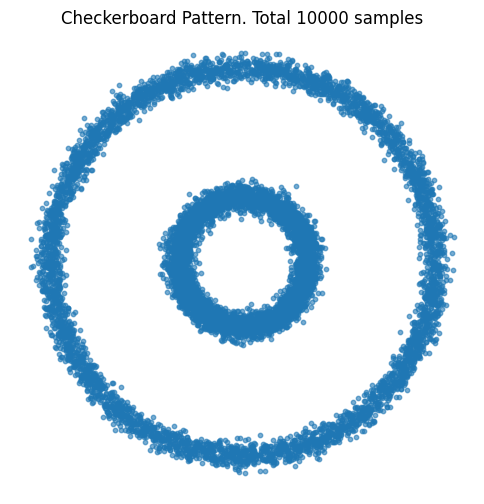

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.manual_seed(1)

def checkerboard(n, grid_size=4):
    """
    Generate a checkerboard pattern dataset.
    
    Parameters:
    -----------
    n : int
        Number of samples to generate
    grid_size : int
        Size of the checkerboard grid (grid_size x grid_size)
    
    Returns:
    --------
    X : ndarray of shape (n, 2)
        Feature matrix with 2D coordinates
    y : ndarray of shape (n,)
        Binary labels (0 or 1) based on checkerboard pattern
    """
    X = []
    y = []
    
    points_per_class = n // 2
    
    # Generate points for class 0 (even sum of grid coordinates)
    count_class_0 = 0
    while count_class_0 < points_per_class:
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 0 and count_class_0 < points_per_class:
                    # Generate point within this square
                    x = np.random.uniform(j, j + 1)
                    y_coord = np.random.uniform(i, i + 1)
                    X.append([x, y_coord])
                    y.append(0)
                    count_class_0 += 1
    
    # Generate points for class 1 (odd sum of grid coordinates)
    count_class_1 = 0
    while count_class_1 < points_per_class:
        for i in range(grid_size):
            for j in range(grid_size):
                if (i + j) % 2 == 1 and count_class_1 < points_per_class:
                    # Generate point within this square
                    x = np.random.uniform(j, j + 1)
                    y_coord = np.random.uniform(i, i + 1)
                    X.append([x, y_coord])
                    y.append(1)
                    count_class_1 += 1
    
    return np.array(X)[np.array(y)==0]

def concentric_circles(n, inner_radius=1.0, outer_radius=3.0, noise=0.1):
    """
    Generate a concentric circles (circle inside of a circle) dataset.
    
    Parameters:
    -----------
    n : int
        Total number of samples to generate (evenly split between classes)
    inner_radius : float
        The base radius of the inner circle (Class 0)
    outer_radius : float
        The base radius of the outer circle (Class 1)
    noise : float
        Standard deviation of Gaussian noise added to the coordinates
    
    Returns:
    --------
    X : ndarray of shape (n, 2)
        Feature matrix with 2D coordinates
    y : ndarray of shape (n,)
        Binary labels (0 for inner circle, 1 for outer circle)
    """
    points_per_class = n // 2
    
    # Generate random angles for all points
    theta_inner = np.random.uniform(0, 2 * np.pi, points_per_class)
    theta_outer = np.random.uniform(0, 2 * np.pi, points_per_class)
    
    # Convert polar to Cartesian for inner circle (Class 0)
    x_inner = inner_radius * np.cos(theta_inner)
    y_inner = inner_radius * np.sin(theta_inner)
    
    # Convert polar to Cartesian for outer circle (Class 1)
    x_outer = outer_radius * np.cos(theta_outer)
    y_outer = outer_radius * np.sin(theta_outer)
    
    # Stack features into separate class arrays
    X_inner = np.vstack((x_inner, y_inner)).T
    X_outer = np.vstack((x_outer, y_outer)).T
    
    # Combine classes into single feature matrix X and label vector y
    X = np.vstack((X_inner, X_outer))
    y = np.hstack((np.zeros(points_per_class), np.ones(points_per_class)))
    
    # Add Gaussian noise if specified
    if noise > 0:
        X += np.random.normal(0, noise, X.shape)
        
    # Shuffle the dataset so rows aren't ordered by class
    indices = np.arange(n)
    np.random.shuffle(indices)
    
    return X[indices], y[indices].astype(int)

# Generate and plot
data = checkerboard(12000, grid_size=5)
data = concentric_circles(10000)[0]
data = torch.tensor(data).float()
data-=data.mean()
data/=data.std()
plt.figure(figsize=(6,6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, s=10)
plt.title(f'Checkerboard Pattern. Total {len(data)} samples')
plt.axis("off")
plt.show()

In [3]:
from kemsekov_torch.flow_matching import FlowModel1d

fm = FlowModel1d(
    data.shape[-1],
    hidden_dim=64,
    residual_blocks=5,
    device='cuda',
    # dropout_p=0.1
)

torch.manual_seed(2)
with torch.no_grad():
    print("logprob before train",fm.log_prob(data).mean())
fm.fit(data,batch_size=512,epochs=512,debug=True)
with torch.no_grad():
    print("logprob after train",fm.log_prob(data).mean())

fm.time_scaler

logprob before train tensor(-2.9161)
Epoch 1: best_loss=3.264	best r2=0.005
Epoch 2: best_loss=2.797	best r2=0.224
Epoch 3: best_loss=2.728	best r2=0.258
Epoch 4: best_loss=2.724	best r2=0.264
Epoch 5: best_loss=2.719	best r2=0.267
Epoch 6: best_loss=2.660	best r2=0.293
Epoch 7: best_loss=2.592	best r2=0.310
Epoch 11: best_loss=2.598	best r2=0.321
Epoch 12: best_loss=2.589	best r2=0.327
Epoch 13: best_loss=2.558	best r2=0.327
Epoch 14: best_loss=2.543	best r2=0.340
Epoch 17: best_loss=2.550	best r2=0.344
Epoch 26: best_loss=2.526	best r2=0.351
Epoch 38: best_loss=2.515	best r2=0.353
Epoch 39: best_loss=2.520	best r2=0.362
Epoch 53: best_loss=2.476	best r2=0.363
Epoch 61: best_loss=2.490	best r2=0.366
Epoch 65: best_loss=2.482	best r2=0.368
Epoch 69: best_loss=2.460	best r2=0.376
Epoch 83: best_loss=2.489	best r2=0.381
Epoch 103: best_loss=2.433	best r2=0.382
Epoch 126: best_loss=2.441	best r2=0.388
Epoch 154: best_loss=2.444	best r2=0.393
Epoch 176: best_loss=2.429	best r2=0.395
Epoch 

Parameter containing:
tensor([50.2733], device='cuda:0', requires_grad=True)

Text(0.5, 1.0, 'Training metric')

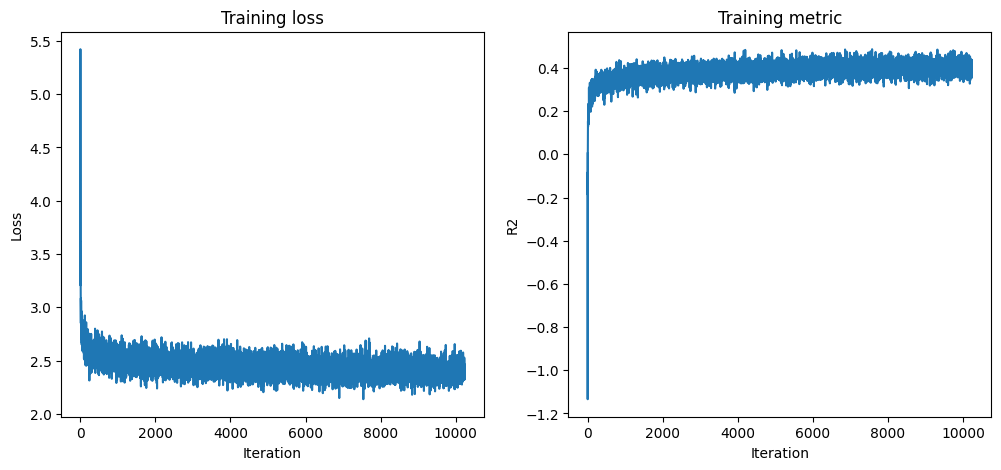

In [4]:
from matplotlib import pyplot as plt

fig,ax = plt.subplots(ncols=2,figsize=(12,5))
ax[0].plot(fm.fit_history['loss'])
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training loss")

ax[1].plot(fm.fit_history['r2'])
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("R2")
ax[1].set_title("Training metric")


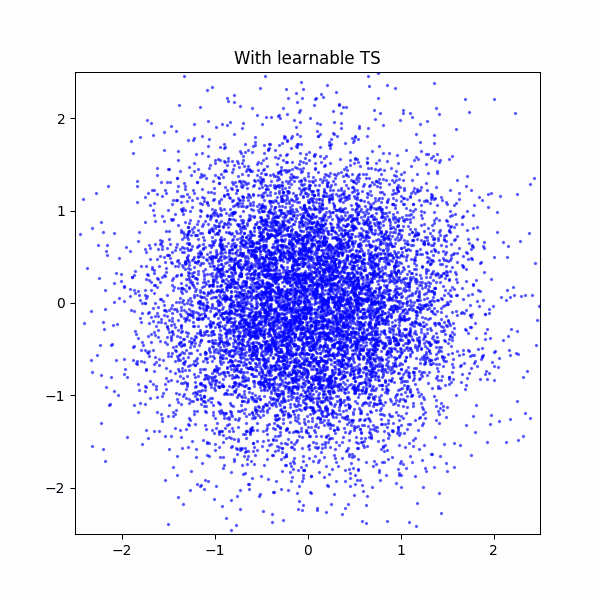

In [5]:
import matplotlib.animation as animation
from IPython.display import Image, display

with torch.no_grad():
    normal_noise = torch.randn((len(data),2))
    a,b = fm.fm.integrate(fm,normal_noise.to(fm.device),steps=32,return_intermediates=True)
    a = a.cpu()
    b=[i.cpu() for i in b]
    b=[b[0]]*2+b+[b[-1]]*6
fig, ax = plt.subplots(figsize=(6, 6))

# Initialize scatter plot
scatter = ax.scatter([], [], s=2, alpha=0.5, c='blue')

# Set axis limits (adjust based on your data range)
ax.set_xlim(-2.5, 2.5)  # Adjust based on your data
ax.set_ylim(-2.5, 2.5)  # Adjust based on your data
ax.set_title('With learnable TS')

# Animation update function
def update(frame):
    data = b[frame][:,[0,1]]
    scatter.set_offsets(data)
    # ax.set_title(f'Animation Frame {frame + 1}/{len(b)}')
    return scatter,

# Create animation
ani = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(b), 
    interval=100,  # milliseconds between frames
    blit=True
)

# Save as GIF
ani.save('animation.gif', writer='pillow', fps=10)

# Display in notebook
plt.close(fig)  # Close the static figure

display(Image(filename="animation.gif"))

In [6]:
from copy import deepcopy

fm_reflow = deepcopy(fm)
torch.manual_seed(0)
fm_reflow.reflow(data,epochs=2048,batch_size=512,lr=0.01,steps=1)

with torch.no_grad():
    print("logprob after reflow",fm_reflow.log_prob(data).mean())

logprob after reflow tensor(-1.3218)


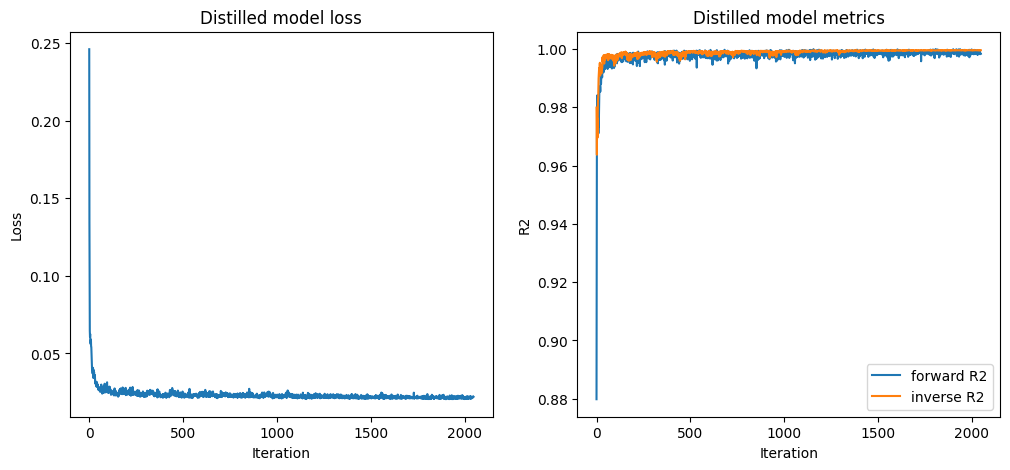

In [7]:
fig,ax = plt.subplots(ncols=2,figsize=(12,5))
ax[0].plot(fm_reflow.reflow_history['loss'])
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Loss")
ax[0].set_title("Distilled model loss")

ax[1].plot(fm_reflow.reflow_history['forward_r2'],label='forward R2')
ax[1].plot(fm_reflow.reflow_history['inverse_r2'],label='inverse R2')
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("R2")
ax[1].set_title("Distilled model metrics")
ax[1].legend()

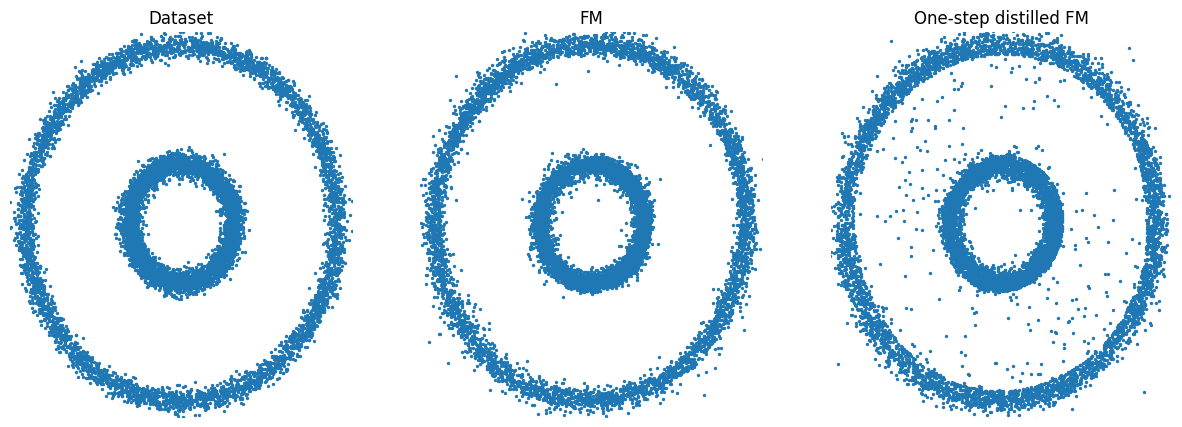

In [52]:
from matplotlib import pyplot as plt
import numpy as np
from kemsekov_torch.common_modules import mmd_rbf

n = len(data)
with torch.no_grad():
    fm_sample = fm.sample(n,steps=16).cpu()
    reflow_sample = fm_reflow.sample(n).cpu()
    

ax = plt.subplots(ncols=3,figsize=(15,5))[1]

ax[0].scatter(data[:,0],data[:,1],s=2)
ax[0].set_xlim(data[:,0].min(),data[:,0].max())
ax[0].set_ylim(data[:,1].min(),data[:,1].max())
ax[0].set_title("Dataset")
ax[0].axis("off")

ax[1].scatter(fm_sample[:,0],fm_sample[:,1],s=2)
ax[1].set_xlim(data[:,0].min(),data[:,0].max())
ax[1].set_ylim(data[:,1].min(),data[:,1].max())
ax[1].set_title(f"FM")
ax[1].axis("off")

ax[2].scatter(reflow_sample[:,0],reflow_sample[:,1],s=2)
ax[2].set_xlim(data[:,0].min(),data[:,0].max())
ax[2].set_ylim(data[:,1].min(),data[:,1].max())
ax[2].set_title(f"One-step distilled FM")
ax[2].axis("off")
plt.show()

In [9]:
from copy import deepcopy

fm_reflow_freeze = deepcopy(fm)
torch.manual_seed(0)
fm_reflow_freeze.reflow(data,epochs=2048,batch_size=512,lr=0.01,freeze_integrator=True,steps=1)

with torch.no_grad():
    print("logprob after reflow+freeze",fm_reflow_freeze.log_prob(data).mean())

logprob after reflow+freeze tensor(-1.5882)


(np.float64(-2.0836429595947266),
 np.float64(2.0796103477478027),
 np.float64(-2.0624186992645264),
 np.float64(2.0388236045837402))

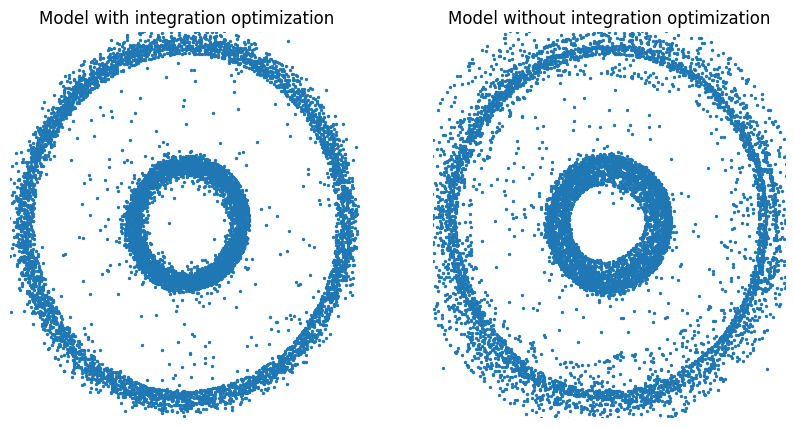

In [10]:
with torch.no_grad():
    freeze_reflow_sample = fm_reflow_freeze.sample(n).cpu()
ax = plt.subplots(ncols=2,figsize=(10,5))[1]

ax[0].scatter(reflow_sample[:,0],reflow_sample[:,1],s=2)
ax[0].set_xlim(data[:,0].min(),data[:,0].max())
ax[0].set_ylim(data[:,1].min(),data[:,1].max())
ax[0].set_title("Model with integration optimization")
ax[0].axis("off")

ax[1].scatter(freeze_reflow_sample[:,0],freeze_reflow_sample[:,1],s=2)
ax[1].set_xlim(data[:,0].min(),data[:,0].max())
ax[1].set_ylim(data[:,1].min(),data[:,1].max())
ax[1].set_title("Model without integration optimization")
ax[1].axis("off")

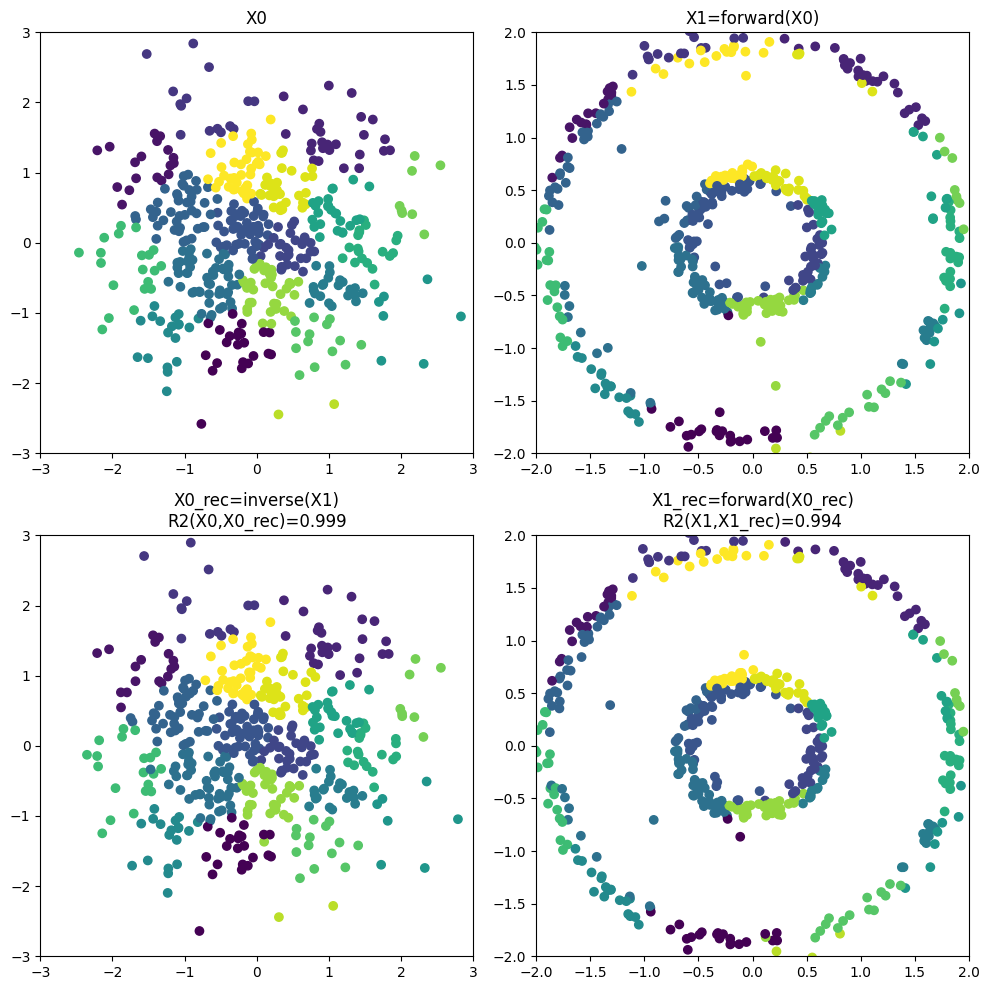

In [11]:
# check inevitability of the model
from kemsekov_torch.fast_pytorch_kmeans.kmeans import KMeans
from kemsekov_torch.metrics import r2_score


x0 = torch.randn((500,2))
c = KMeans(n_clusters=20).fit_predict(x0)

with torch.no_grad():
    x1 = fm_reflow.to_target(x0)
    x0_1 = fm_reflow.to_prior(x1)
    x1_0 = fm_reflow.to_target(x0_1)

x0_rec_r2 = r2_score(x0,x0_1)
x1_rec_r2 = r2_score(x1,x1_0)

plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.scatter(x0[:,0],x0[:,1],c=c)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title("X0")

plt.subplot(2,2,2)
plt.scatter(x1[:,0],x1[:,1],c=c)
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.title("X1=forward(X0)")

plt.subplot(2,2,3)
plt.scatter(x0_1[:,0],x0_1[:,1],c=c)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title(f"X0_rec=inverse(X1)\nR2(X0,X0_rec)={x0_rec_r2:0.3f}")

plt.subplot(2,2,4)
plt.scatter(x1_0[:,0],x1_0[:,1],c=c)
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.title(f"X1_rec=forward(X0_rec)\nR2(X1,X1_rec)={x1_rec_r2:0.3f}")

plt.tight_layout()

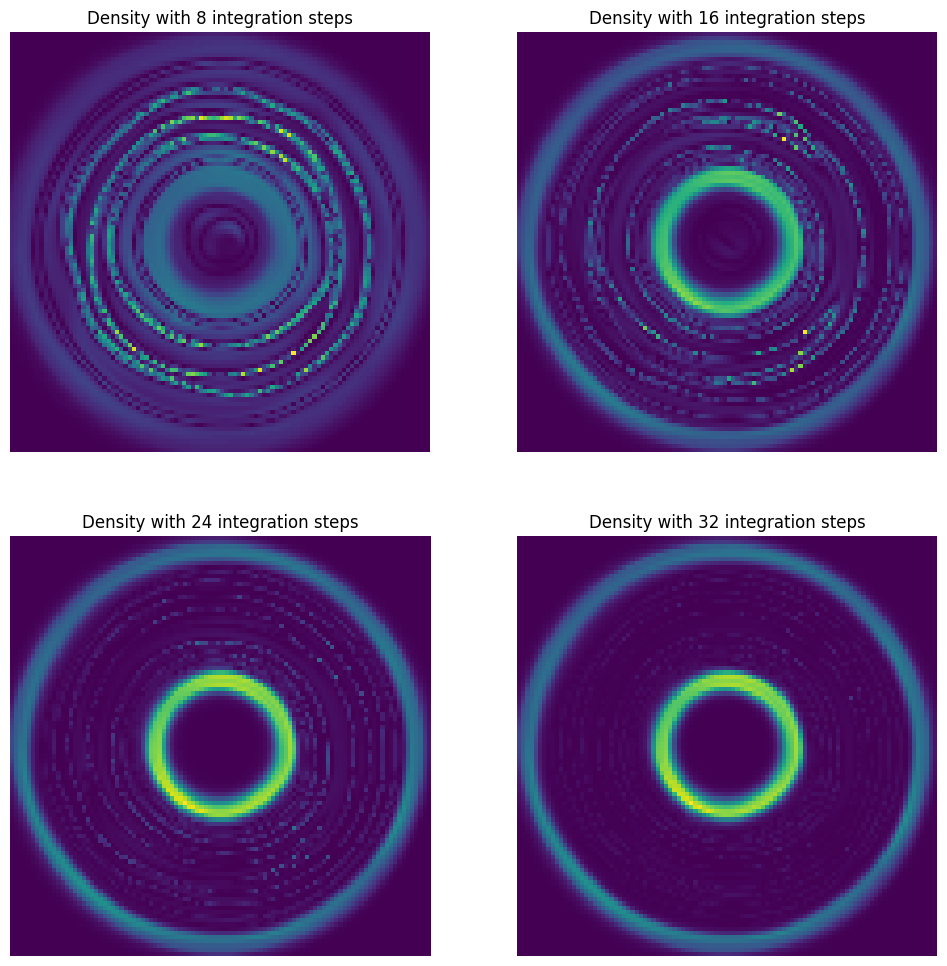

In [47]:
X = torch.linspace(-2,2,100)
Y = torch.linspace(-2,2,100)
grid = torch.stack(torch.meshgrid([X,Y],indexing="ij"),-1)
model = fm

plt.figure(figsize=(12,12))
for i,s in enumerate([8,16,24,32]):
    fm.default_steps=s
    with torch.no_grad():
        x = grid.view(-1,2)
        probs = model.log_prob(x,eps=0.01).view(grid.shape[:-1])
    plt.subplot(2,2,i+1)
    plt.imshow((probs.T).sigmoid())
    plt.axis('off')
    plt.title(f"Density with {fm.default_steps} integration steps")

Text(0.5, 1.0, 'Distilled model density')

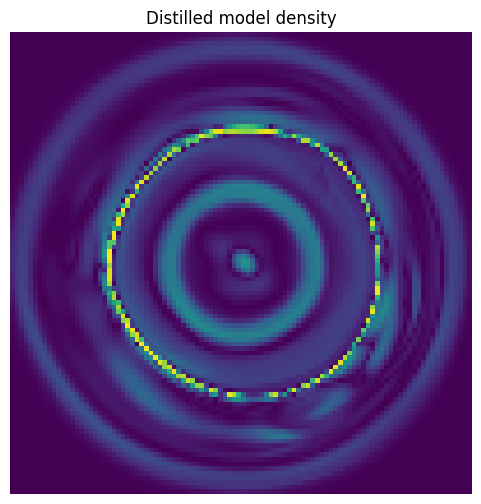

In [53]:
model = fm_reflow

plt.figure(figsize=(6,6))
with torch.no_grad():
    x = grid.view(-1,2)
    probs = model.log_prob(x,eps=0.01).view(grid.shape[:-1])
plt.imshow((probs.T).sigmoid())
plt.axis('off')
plt.title(f"Distilled model density")

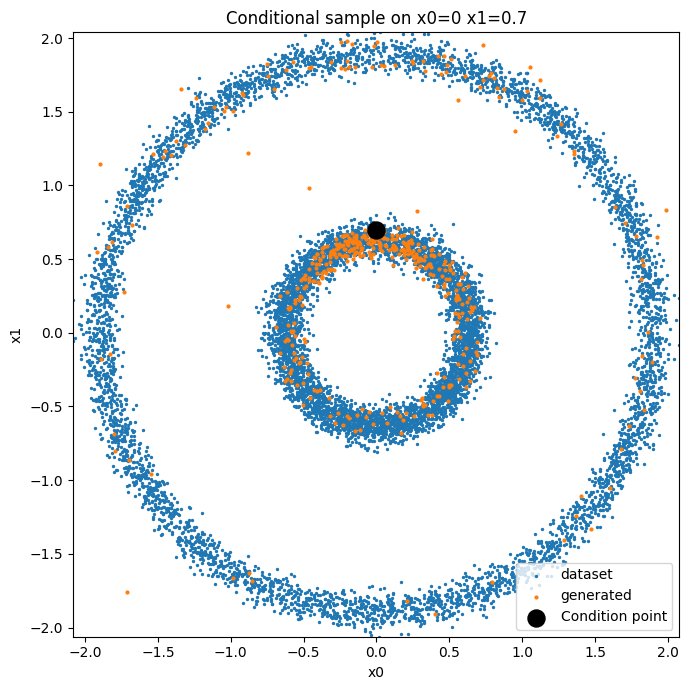

In [18]:
x0 = 0
x1 = 0.7
def constraint(x):
    a = ((x[:,0]-x0)**2).mean()
    b = ((x[:,1]-x1)**2).mean()
    return a+b

constrained_samples = fm_reflow.conditional_sample(
    constraint=constraint,
    num_samples=500,
    noise_scale=0.1,
    steps=1,
    mode_closeness_weight=1
)[:,:3].cpu()

plt.figure(figsize=(7,7))
plt.scatter(data[:,0],data[:,1],s=2,label='dataset')
plt.scatter(constrained_samples[:,0],constrained_samples[:,1],s=4,label='generated')
plt.scatter([x0],[x1],s=150,c='black',label='Condition point')
plt.title(f"Conditional sample on x0={x0} x1={x1}")
plt.xlabel("x0")
plt.ylabel("x1")
plt.xlim(data[:,0].min(),data[:,0].max())
plt.ylim(data[:,1].min(),data[:,1].max())
plt.tight_layout()
plt.legend()

(np.float64(-3.5), np.float64(3.5), np.float64(-3.5), np.float64(3.5))

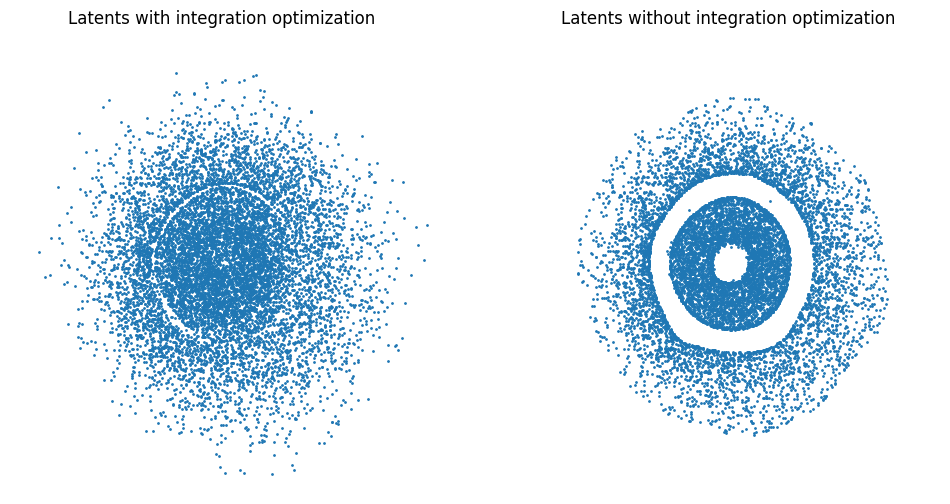

In [14]:
with torch.no_grad():
    latent_freeze = fm_reflow_freeze.to_prior(data)
    latent_reflow = fm_reflow.to_prior(data)


plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(latent_reflow[:,0],latent_reflow[:,1],s=1)
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.title("Latents with integration optimization")
plt.axis('off')

plt.subplot(1,2,2)
plt.scatter(latent_freeze[:,0],latent_freeze[:,1],s=1)
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.title("Latents without integration optimization")
plt.axis('off')


For given random vector

In [30]:
fm.default_steps=32

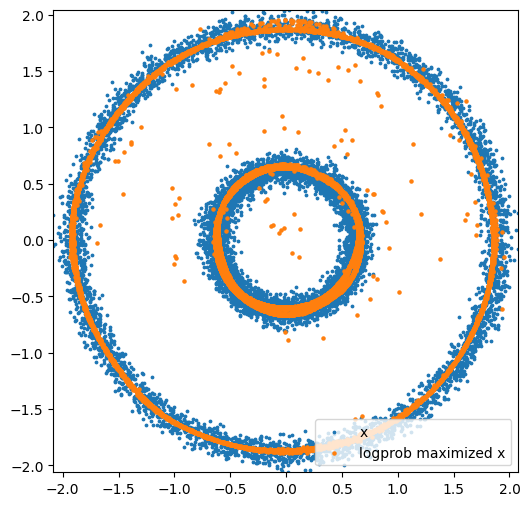

In [ ]:
data_opt,loss = fm_reflow.optimize(data)
data_opt=data_opt.detach()
plt.figure(figsize=(6,6))
plt.scatter(data[:,0],data[:,1],s=3,label='x')
plt.scatter(data_opt[:,0],data_opt[:,1],s=5,label='logprob maximized x')
plt.xlim(data[:,0].min(),data[:,0].max())
plt.ylim(data[:,1].min(),data[:,1].max())
plt.legend()

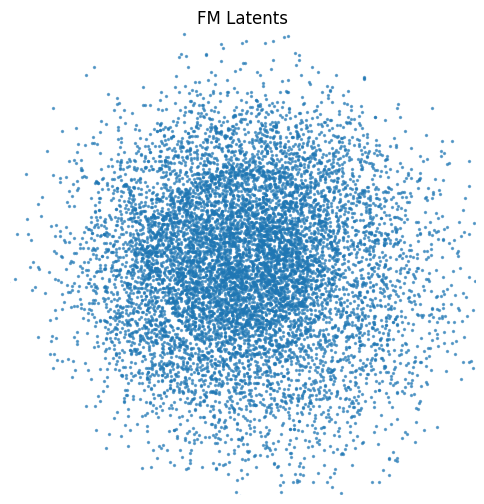

In [61]:
# prior = torch.randn_like(data)
with torch.no_grad():
    prior = fm.to_prior(data)
plt.figure(figsize=(6,6))
plt.scatter(prior[:, 0], prior[:, 1], alpha=0.6, s=2)
plt.axis('off')
plt.title("FM Latents")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.show()